In [1]:
!apt-get install -y mpich
!pip install mpi4py
!pip install spacy beautifulsoup4 requests
!python -m spacy download en_core_web_sm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mpich is already the newest version (4.0-3).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
%%writefile climate_mpi.py
from mpi4py import MPI
import requests
from bs4 import BeautifulSoup
import spacy
import sys
import time

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "textcat"])
except OSError:
    print("Spacy model not found.")
    sys.exit(1)

def get_links_from_main_page(url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) target-parser'}
        response = requests.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(response.content, 'html.parser')

        target_links = []
        navs = soup.find_all(['div', 'table'], class_='navbox')
        for nav in navs:
            if "Climate of the United States" in nav.get_text():
                for link in nav.find_all('a'):
                    href = link.get('href')
                    title = link.get('title')
                    if href and title and "/wiki/" in href and ":" not in href:
                        target_links.append((title, "https://en.wikipedia.org" + href))
                break

        unique_links = list(dict.fromkeys(target_links))
        return unique_links
    except Exception as e:
        return []

def clean_and_analyze(item):
    title, url = item
    try:
        time.sleep(0.1 * rank)

        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(response.content, 'html.parser')

        for unwanted in soup.find_all(['div', 'table'], class_=['mw-jump-link', 'navbox', 'sistersitebox']):
            unwanted.decompose()

        content_div = soup.find('div', id='mw-content-text')
        if not content_div:
            return (title, 0)

        ref_header = None
        for h in content_div.find_all(['h2', 'h3']):
            t = h.get_text().lower()
            if 'references' in t or 'external links' in t or 'notes' in t:
                ref_header = h
                break

        if ref_header:
            for sibling in ref_header.find_all_next():
                sibling.decompose()
            ref_header.decompose()

        text = content_div.get_text(separator=' ', strip=True)
        doc = nlp(text[:500000])

        geo_count = len([ent for ent in doc.ents if ent.label_ in ['GPE', 'LOC']])
        return (title, geo_count)
    except:
        return (title, 0)

start_time = MPI.Wtime()
main_url = "https://en.wikipedia.org/wiki/Climate_of_the_United_States"

if rank == 0:
    all_links = get_links_from_main_page(main_url)
    if not all_links:
        all_links = [("Climate of " + s, f"https://en.wikipedia.org/wiki/Climate_of_{s.replace(' ', '_')}")
                     for s in ["California", "Texas", "Florida", "Alaska", "Virginia", "New York", "Arizona"]]

    chunks = [all_links[i::size] for i in range(size)]
else:
    chunks = None

my_links = comm.scatter(chunks, root=0)
my_results = [clean_and_analyze(link) for link in my_links]
gathered_data = comm.gather(my_results, root=0)
end_time = MPI.Wtime()

if rank == 0:
    final_results = [res for sub in gathered_data for res in sub]
    final_results.sort(key=lambda x: x[1], reverse=True)

    print("\n" + "="*50)
    print(f"ИТОГИ (Процессов: {size}) | Время: {end_time - start_time:.2f} сек")
    print("="*50)
    valid_results = [r for r in final_results if r[1] > 0]
    for i, (name, count) in enumerate(valid_results[:5], 1):
        print(f"{i}. {name}: {count} объектов")
    if not valid_results:
        print("Данные не были получены. Проверьте соединение или URL.")
    print("="*50 + "\n")

Overwriting climate_mpi.py


ЗАПУСК ТЕСТА (2 ПРОЦЕССОВ)...

ИТОГИ (Процессов: 2) | Время: 162.93 сек
1. Climate of Maryland: 938 объектов
2. Climate of Colorado: 878 объектов
3. Climate of Louisiana: 861 объектов
4. Climate of Michigan: 830 объектов
5. Climate of Tennessee: 807 объектов

Тест завершен. Время: 174.97 сек

------------------------------------------------------------

ЗАПУСК ТЕСТА (3 ПРОЦЕССОВ)...

ИТОГИ (Процессов: 3) | Время: 151.84 сек
1. Climate of Maryland: 938 объектов
2. Climate of Colorado: 878 объектов
3. Climate of Louisiana: 861 объектов
4. Climate of Michigan: 830 объектов
5. Climate of Tennessee: 807 объектов

Тест завершен. Время: 164.34 сек

------------------------------------------------------------

ЗАПУСК ТЕСТА (6 ПРОЦЕССОВ)...

ИТОГИ (Процессов: 6) | Время: 175.43 сек
1. Climate of Maryland: 938 объектов
2. Climate of Colorado: 878 объектов
3. Climate of Louisiana: 861 объектов
4. Climate of Michigan: 830 объектов
5. Climate of Tennessee: 807 объектов

Тест завершен. Время: 201.74

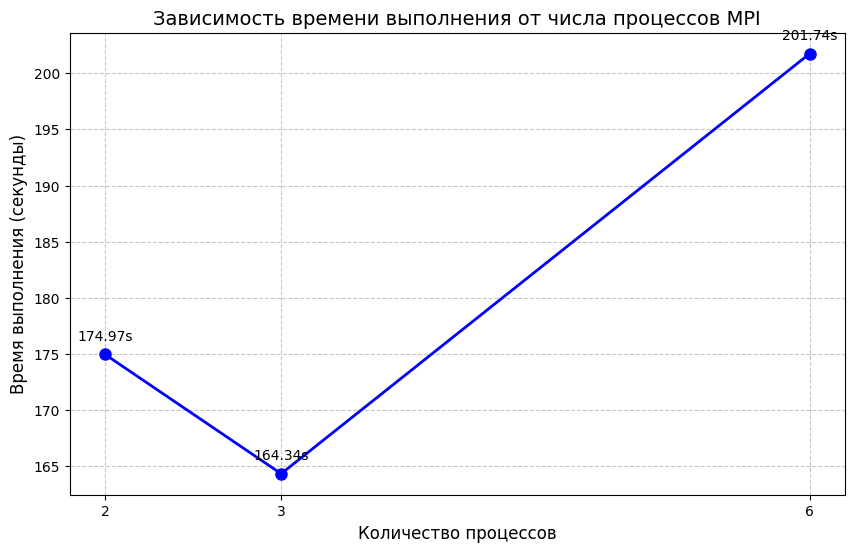

In [6]:
import time
import matplotlib.pyplot as plt

results = []

def run_test(n_procs):
    print(f"ЗАПУСК ТЕСТА ({n_procs} ПРОЦЕССОВ)...")
    start = time.time()
    !mpirun --allow-run-as-root --oversubscribe -n {n_procs} python climate_mpi.py
    end = time.time()
    elapsed = end - start
    results.append((n_procs, elapsed))
    print(f"Тест завершен. Время: {elapsed:.2f} сек")
    print("\n" + "-"*60 + "\n")

process_counts = [2, 3, 6]
for count in process_counts:
    run_test(count)

if results:
    counts, times = zip(*results)

    plt.figure(figsize=(10, 6))
    plt.plot(counts, times, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

    plt.title('Зависимость времени выполнения от числа процессов MPI', fontsize=14)
    plt.xlabel('Количество процессов', fontsize=12)
    plt.ylabel('Время выполнения (секунды)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(process_counts)

    for i, txt in enumerate(times):
        plt.annotate(f"{txt:.2f}s", (counts[i], times[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.show()